In [20]:
# 📊 Credit Risk & Loan Default Analytics

## Phase 07 – Executive Dashboard

### Objectives
#Executive KPIs
# Portfolio Overview
# Financial Overview
# Customer Overview
# Correlation Analysis
#Executive Summary
###


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Plot Style
plt.style.use("ggplot")

# Seaborn Theme
sns.set_theme(style="whitegrid")

# Figure Size
plt.rcParams["figure.figsize"] = (10, 6)

# Font Size
plt.rcParams["font.size"] = 11

# High Resolution
plt.rcParams["figure.dpi"] = 120

# Display All Columns
pd.set_option("display.max_columns", None)

# Display All Rows (Optional)
# pd.set_option("display.max_rows", None)

In [3]:
df = pd.read_csv("../DATA/cleaned_loan_data.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (120720, 53)


,loan_id,applicant_id,customer_name,gender,date_of_birth,age,marital_status,education,occupation,employment_type,employer_name,years_with_employer,annual_income,monthly_income,city,state,pincode,branch_id,branch_name,region,loan_product,loan_purpose,loan_amount,sanctioned_amount,disbursed_amount,interest_rate,tenure_months,emi_amount,processing_fee,credit_score,debt_to_income_ratio,existing_loans_count,existing_emi_obligations,collateral_type,collateral_value,co_applicant_flag,application_date,approval_date,disbursal_date,loan_status,default_flag,days_past_due,npa_flag,recovery_amount,loan_officer_id,loan_officer_name,payment_history_score,bounce_count,risk_category,customer_segment,is_fraud_suspected,kyc_verified,channel
0,LN157322,AP257322,Sunil Mukherjee,Male,1998-10-02,28,Married,Post Graduate,Retail Business Owner,Business Owner,Self Employed,7.8,723600.0,43900.0,Gurugram,Haryana,140909,BR013,Gurugram City Branch,North,Personal Loan,Medical Emergency,552000.0,542000.0,539000.0,18.32,48,15923.0,6594.0,680.0,0.756,2,17250.0,NaN,0.0,Yes,2025-09-21,2025-09-27,2025-10-01,Default,1,228.0,Yes,95223.0,OFF0073,Vivaan Kulkarni,446.0,5,Low,Mass Market,No,Yes,Digital App
1,LN200595,AP300595,Dinesh Naidu,Male,2003-04-13,23,Married,Post Graduate,Trading Company Owner,Business Owner,Self Employed,10.1,685200.0,57100.0,Patna,Bihar,424815,BR014,Patna City Branch,East,Personal Loan,Travel,237000.0,235000.0,232000.0,17.00,51,6419.0,1947.0,697.0,0.151,1,2212.0,NaN,0.0,No,2023-01-26,2023-01-28,2023-01-30,Active,0,0.0,No,0.0,OFF0080,Aarav Patil,900.0,1,Low,Mass Market,No,Yes,Digital App
2,LN152399,AP252399,Karan Naidu,Male,1990-02-11,36,Divorced,Professional Degree,Manager,Salaried,Tata Motors,0.5,816000.0,68000.0,Chennai,Tamil Nadu,161492,BR019,Chennai City Branch,South,Gold Loan,Emergency Cash Need,912000.0,870000.0,853000.0,10.50,16,57364.0,16721.0,633.0,0.844,0,0.0,Gold Ornaments,0.0,No,2025-07-23,2025-08-01,2025-08-04,Active,0,0.0,No,0.0,OFF0112,Usha Sinha,836.0,1,Low,Mass Affluent,No,Yes,Branch Walk-in
3,LN192773,AP292773,Vihaan Rathore,Male,1979-11-04,47,Married,Professional Degree,Bank Employee,Salaried,Accenture,1.9,2404800.0,200400.0,Rohini,Delhi,351737,BR003,Rohini City Branch,North,Personal Loan,Education,1722000.0,1682000.0,1643000.0,17.01,50,46092.0,8461.0,465.0,0.297,1,13431.0,NaN,0.0,No,2025-05-07,2025-06-07,2025-07-09,Active,0,0.0,No,0.0,OFF0015,Aarav More,868.0,0,Low,Premium,No,Yes,Corporate Tie-up
4,LN133442,AP233442,Komal Pillai,Female,1974-11-06,52,Married,Post Graduate,Freelancer,Self-Employed Business,Self Employed,3.0,633600.0,52800.0,Ludhiana,Punjab,267456,BR025,Ludhiana Main Branch,North,Personal Loan,Travel,562000.0,511000.0,509000.0,16.83,43,15844.0,6414.0,699.0,0.300,0,0.0,NaN,0.0,No,2025-09-14,2025-09-23,2025-09-26,Active,0,0.0,No,0.0,OFF0146,Sneha Bhatt,882.0,0,Low,Mass Market,No,Yes,Tele-calling


In [17]:
df.to_csv("../DATA/cleaned_loan_data.csv", index=False)

print("✅ Cleaned dataset saved successfully.")

✅ Cleaned dataset saved successfully.


In [21]:
# Executive KPI Dashboard


In [23]:
print(df["npa_flag"].value_counts())

npa_flag
No     114770
Yes      5230
Name: count, dtype: int64


In [24]:
npa_rate = (df["npa_flag"] == "Yes").mean() * 100

In [25]:
print(df["default_flag"].value_counts())
print("-"*30)
print(df["npa_flag"].value_counts())

default_flag
0    113616
1      6384
Name: count, dtype: int64
------------------------------
npa_flag
No     114770
Yes      5230
Name: count, dtype: int64


In [26]:
# ================================
# Executive KPI Dashboard
# ================================

# Total Customers
total_customers = df["applicant_id"].nunique()

# Total Loans
total_loans = df["loan_id"].nunique()

# Total Loan Amount
total_loan_amount = df["loan_amount"].sum()

# Total Disbursed Amount
total_disbursed = df["disbursed_amount"].sum()

# Total Recovery Amount
total_recovery = df["recovery_amount"].sum()

# Default Rate (%)
default_rate = df["default_flag"].mean() * 100

# NPA Rate (%)
npa_rate = (df["npa_flag"] == "Yes").mean() * 100

# Average Credit Score
avg_credit_score = df["credit_score"].mean()

# Average Interest Rate
avg_interest_rate = df["interest_rate"].mean()

In [27]:
kpi = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Loans",
        "Total Loan Amount",
        "Total Disbursed Amount",
        "Total Recovery Amount",
        "Default Rate (%)",
        "NPA Rate (%)",
        "Average Credit Score",
        "Average Interest Rate (%)"
    ],

    "Value": [
        f"{total_customers:,}",
        f"{total_loans:,}",
        f"₹ {total_loan_amount:,.0f}",
        f"₹ {total_disbursed:,.0f}",
        f"₹ {total_recovery:,.0f}",
        f"{default_rate:.2f}%",
        f"{npa_rate:.2f}%",
        f"{avg_credit_score:.0f}",
        f"{avg_interest_rate:.2f}%"
    ]
})

kpi

,KPI,Value
0,Total Customers,"120,000"
1,Total Loans,"120,000"
2,Total Loan Amount,"₹ 72,972,752,810"
3,Total Disbursed Amount,"₹ 67,165,376,000"
4,Total Recovery Amount,"₹ 912,425,445"
5,Default Rate (%),5.32%
6,NPA Rate (%),4.36%
7,Average Credit Score,680
8,Average Interest Rate (%),14.39%


In [28]:
print(f"""
📊 Executive Dashboard Summary

• Total Customers : {total_customers:,}
• Total Loans : {total_loans:,}

• Portfolio Size : ₹{total_loan_amount:,.0f}

• Total Disbursed : ₹{total_disbursed:,.0f}

• Total Recovery : ₹{total_recovery:,.0f}

• Default Rate : {default_rate:.2f}%

• NPA Rate : {npa_rate:.2f}%

The loan portfolio maintains a default rate of {default_rate:.2f}% and an NPA rate
of {npa_rate:.2f}%, providing an overall snapshot of portfolio quality.
""")


📊 Executive Dashboard Summary

• Total Customers : 120,000
• Total Loans : 120,000

• Portfolio Size : ₹72,972,752,810

• Total Disbursed : ₹67,165,376,000

• Total Recovery : ₹912,425,445

• Default Rate : 5.32%

• NPA Rate : 4.36%

The loan portfolio maintains a default rate of 5.32% and an NPA rate
of 4.36%, providing an overall snapshot of portfolio quality.



In [29]:
loan_status = (
    df["loan_status"]
    .value_counts()
    .reset_index()
)

loan_status.columns = ["Loan Status", "Count"]

loan_status

,Loan Status,Count
0,Active,83752
1,Closed,29864
2,Default,5909
3,Written-Off,475


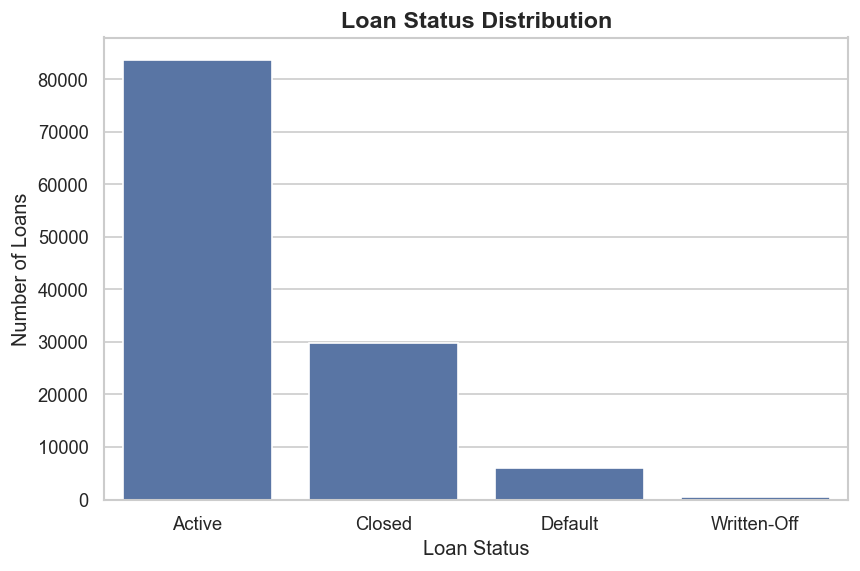

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=loan_status,
    x="Loan Status",
    y="Count"
)

plt.title("Loan Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.show()

In [32]:
top_status = df["loan_status"].mode()[0]
percentage = df["loan_status"].value_counts(normalize=True).iloc[0] * 100

print(f"""
📌 Executive Insight

• '{top_status}' is the most common loan status.

• It represents {percentage:.2f}% of the total loan portfolio.

• This provides a quick overview of the current portfolio composition.
""")


📌 Executive Insight

• 'Active' is the most common loan status.

• It represents 69.79% of the total loan portfolio.

• This provides a quick overview of the current portfolio composition.



In [33]:
loan_product = (
    df["loan_product"]
    .value_counts()
    .reset_index()
)

loan_product.columns = ["Loan Product", "Count"]

loan_product

,Loan Product,Count
0,Personal Loan,47927
1,Auto Loan,30093
2,Business Loan,23947
3,Gold Loan,18033


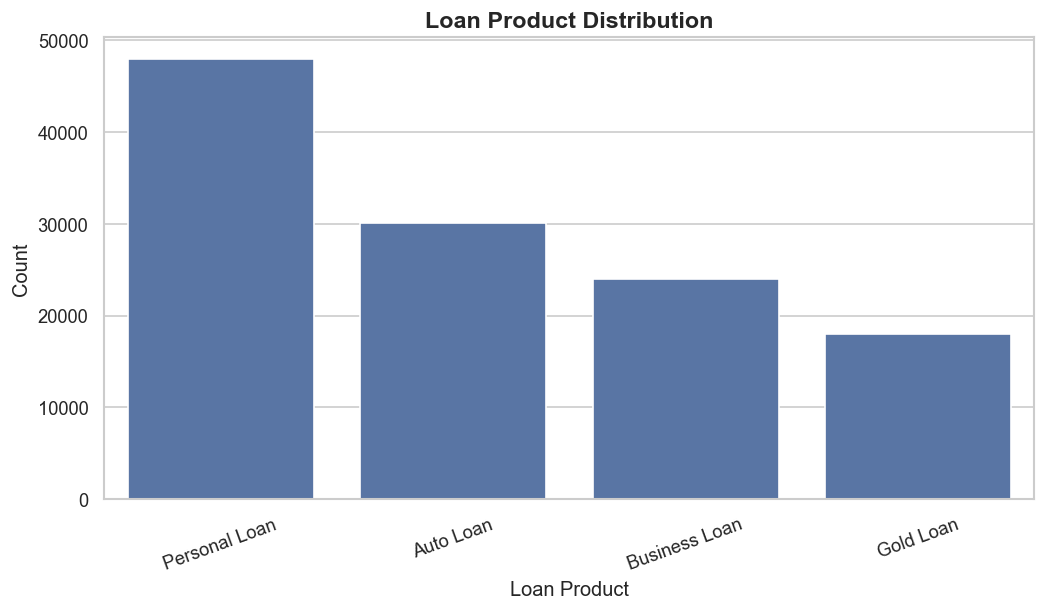

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=loan_product,
    x="Loan Product",
    y="Count"
)

plt.xticks(rotation=20)

plt.title("Loan Product Distribution", fontsize=14, fontweight="bold")

plt.show()

In [35]:
top_product = df["loan_product"].mode()[0]
percentage = df["loan_product"].value_counts(normalize=True).iloc[0] * 100

print(f"""
📌 Executive Insight

• '{top_product}' is the most popular loan product.

• It contributes {percentage:.2f}% of all loans.

• This product is the primary driver of the loan portfolio.
""")


📌 Executive Insight

• 'Personal Loan' is the most popular loan product.

• It contributes 39.94% of all loans.

• This product is the primary driver of the loan portfolio.



In [36]:
region = (
    df.groupby("region")["loan_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

region

,region,loan_amount
0,North,2.627944e+10
1,South,2.344979e+10
2,West,1.164248e+10
3,East,8.775118e+09
4,Central,2.825918e+09


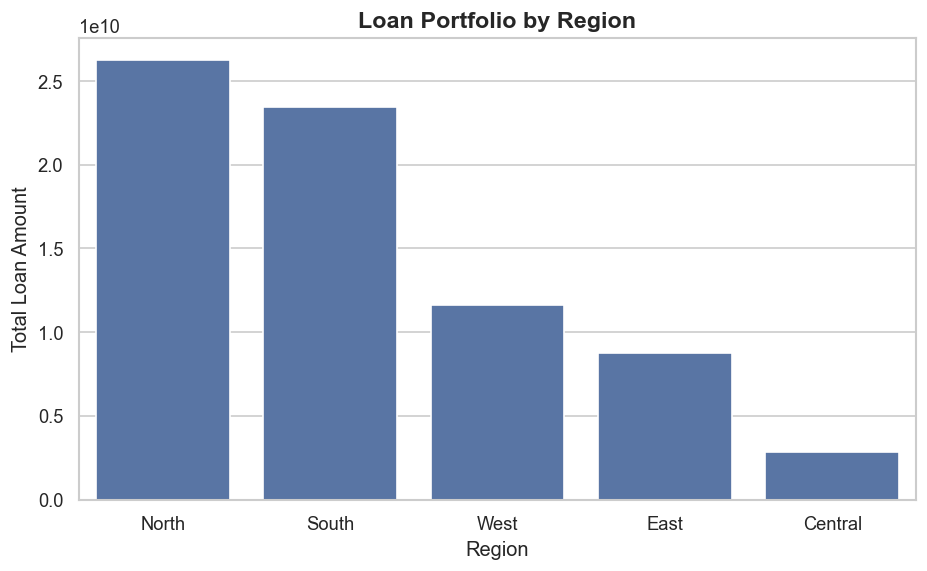

In [37]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=region,
    x="region",
    y="loan_amount"
)

plt.title("Loan Portfolio by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Loan Amount")

plt.show()

In [38]:
top_region = region.iloc[0]["region"]
top_amount = region.iloc[0]["loan_amount"]

print(f"""
📌 Executive Insight

• {top_region} contributes the highest loan portfolio.

• Total Loan Amount: ₹{top_amount:,.0f}

• This region represents the institution's strongest lending market.
""")


📌 Executive Insight

• North contributes the highest loan portfolio.

• Total Loan Amount: ₹26,279,444,702

• This region represents the institution's strongest lending market.



In [40]:
state = (
    df.groupby("state")["loan_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

state

,state,loan_amount
0,Karnataka,5.921004e+09
1,Punjab,5.896076e+09
2,West Bengal,5.892023e+09
3,Gujarat,5.856308e+09
4,Telangana,5.854433e+09
5,Delhi,5.848749e+09
6,Uttar Pradesh,5.819293e+09
7,Maharashtra,5.786177e+09
8,Tamil Nadu,5.764272e+09
9,Rajasthan,5.746815e+09


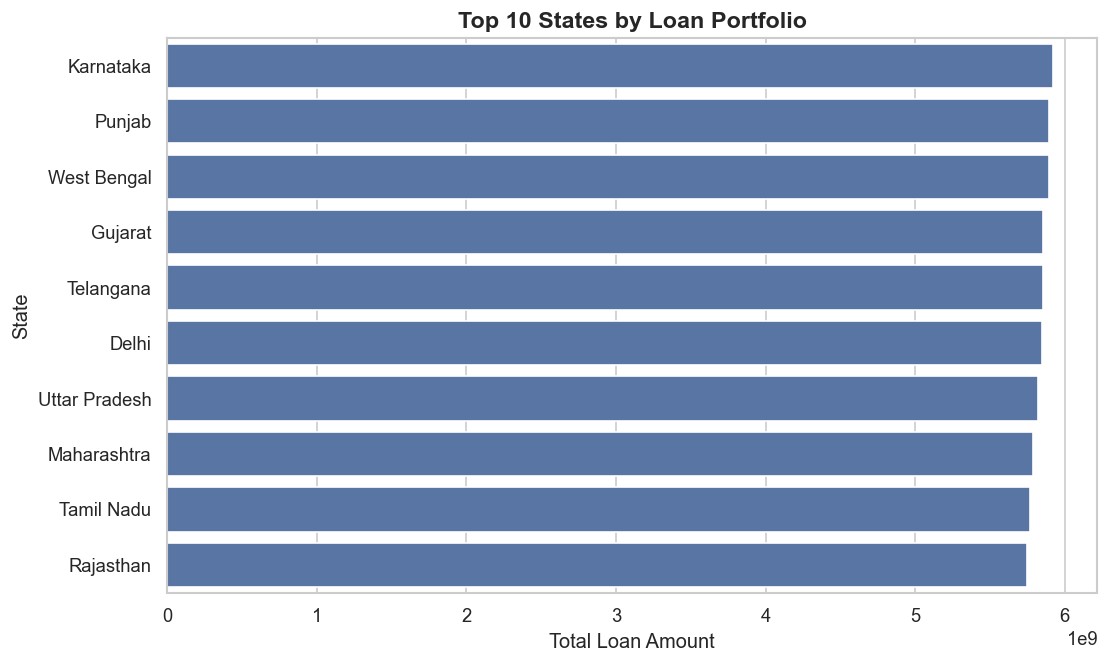

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=state,
    x="loan_amount",
    y="state"
)

plt.title("Top 10 States by Loan Portfolio", fontsize=14, fontweight="bold")
plt.xlabel("Total Loan Amount")
plt.ylabel("State")

plt.show()

In [44]:
top_state = state.iloc[0]["state"]
top_amount = state.iloc[0]["loan_amount"]

print(f"""
📌 Executive Insight

• {top_state} has the largest loan portfolio.

• Total Loan Amount: ₹{top_amount:,.0f}

• The state represents the highest business opportunity.
""")


📌 Executive Insight

• Karnataka has the largest loan portfolio.

• Total Loan Amount: ₹5,921,004,017

• The state represents the highest business opportunity.



In [45]:
branch = (
    df.groupby("branch_name")["loan_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

branch

,branch_name,loan_amount
0,Mysuru City Branch,5.921004e+09
1,Ludhiana Main Branch,5.896076e+09
2,Vadodara City Branch,5.856308e+09
3,Rohini City Branch,5.848749e+09
4,Chennai City Branch,5.764272e+09
5,Jodhpur City Branch,5.746815e+09
6,Warangal Main Branch,2.972648e+09
7,Gurugram City Branch,2.968512e+09
8,Visakhapatnam Main Branch,2.958406e+09
9,Kolkata City Branch,2.957542e+09


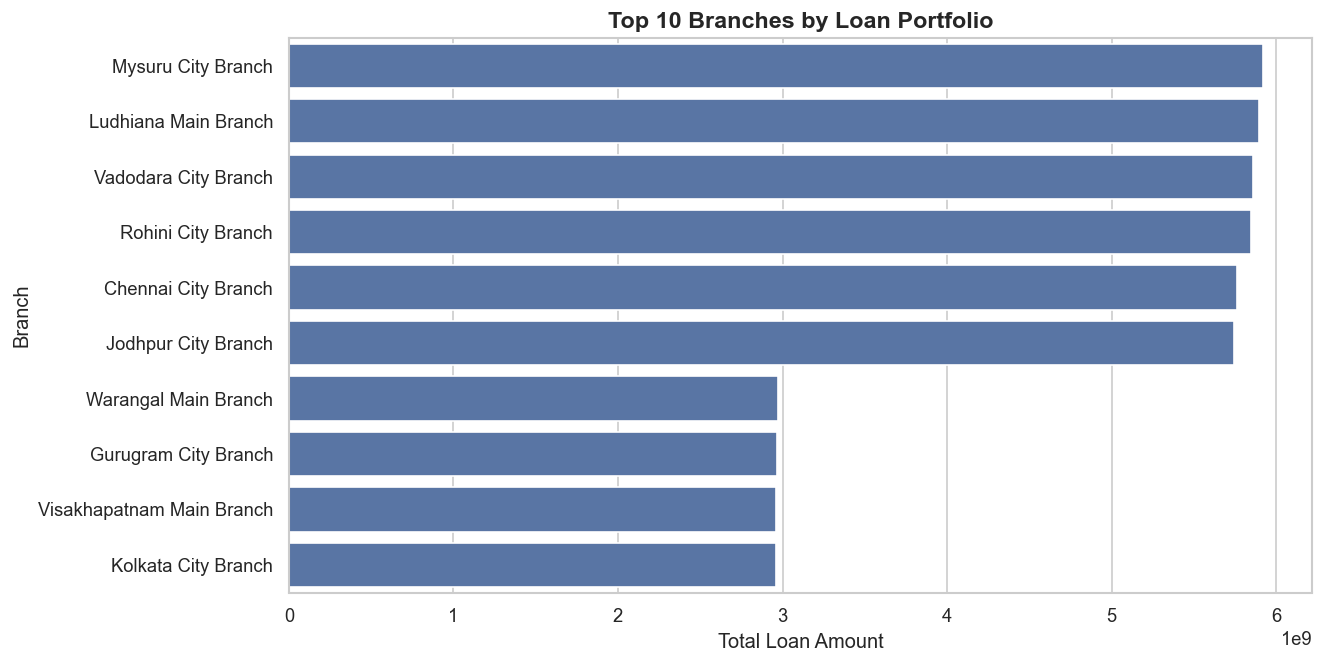

In [46]:
plt.figure(figsize=(11,6))

sns.barplot(
    data=branch,
    x="loan_amount",
    y="branch_name"
)

plt.title("Top 10 Branches by Loan Portfolio", fontsize=14, fontweight="bold")
plt.xlabel("Total Loan Amount")
plt.ylabel("Branch")

plt.show()

In [47]:
top_branch = branch.iloc[0]["branch_name"]
top_amount = branch.iloc[0]["loan_amount"]

print(f"""
📌 Executive Insight

• '{top_branch}' manages the highest loan portfolio.

• Total Loan Amount: ₹{top_amount:,.0f}

• This branch is a key contributor to the institution's lending business.
""")


📌 Executive Insight

• 'Mysuru City Branch' manages the highest loan portfolio.

• Total Loan Amount: ₹5,921,004,017

• This branch is a key contributor to the institution's lending business.



In [49]:
# 🔴 Risk Dashboard

### Objectives
# - Risk Category Distribution
# - Default Analysis
# - NPA Analysis
# - Credit Score Distribution
# - Fraud Analysis
# - Days Past Due (DPD)

In [50]:
risk = (
    df["risk_category"]
    .value_counts()
    .reset_index()
)

risk.columns = ["Risk Category", "Count"]

risk

,Risk Category,Count
0,Low,113345
1,Medium,6107
2,High,536
3,Very High,12


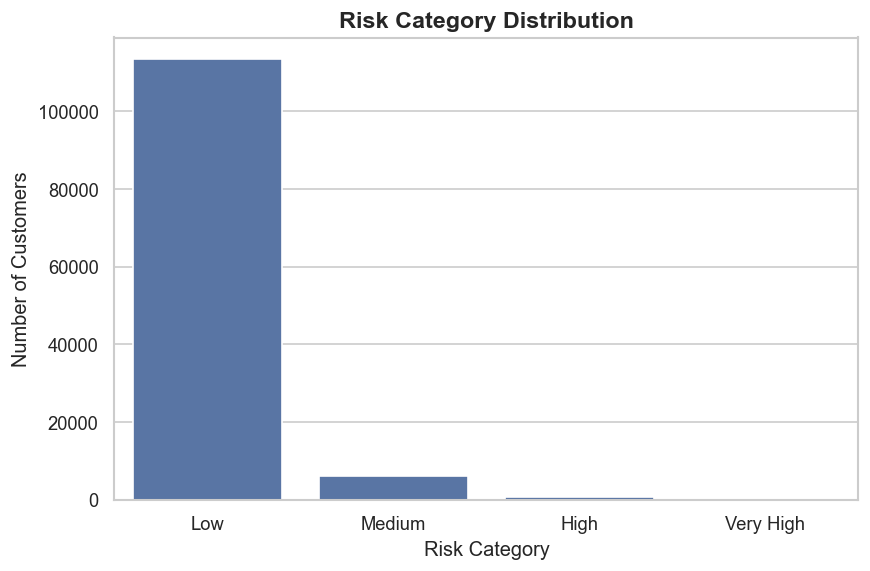

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk,
    x="Risk Category",
    y="Count"
)

plt.title("Risk Category Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

In [52]:
top_risk = df["risk_category"].mode()[0]

percentage = df["risk_category"].value_counts(normalize=True).iloc[0] * 100

print(f"""
📌 Executive Insight

• Most customers belong to the '{top_risk}' risk category.

• It represents {percentage:.2f}% of the total portfolio.

• This indicates the overall risk profile of the lending portfolio.
""")


📌 Executive Insight

• Most customers belong to the 'Low' risk category.

• It represents 94.45% of the total portfolio.

• This indicates the overall risk profile of the lending portfolio.



In [53]:
default = (
    df["default_flag"]
    .value_counts()
    .reset_index()
)

default.columns = ["Default Flag", "Count"]

default["Default Flag"] = default["Default Flag"].map({
    0: "Non Default",
    1: "Default"
})

default

,Default Flag,Count
0,Non Default,113616
1,Default,6384


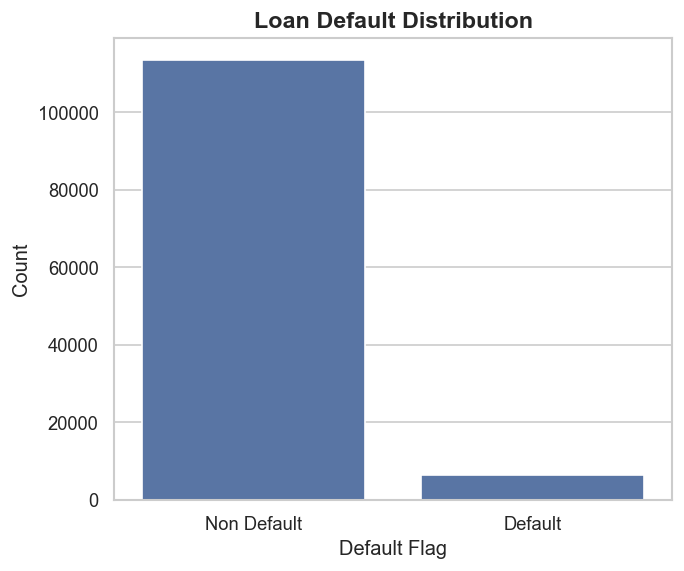

In [54]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=default,
    x="Default Flag",
    y="Count"
)

plt.title("Loan Default Distribution", fontsize=14, fontweight="bold")

plt.show()

In [55]:
npa = (
    df["npa_flag"]
    .value_counts()
    .reset_index()
)

npa.columns = ["NPA Status", "Count"]

npa

,NPA Status,Count
0,No,114770
1,Yes,5230


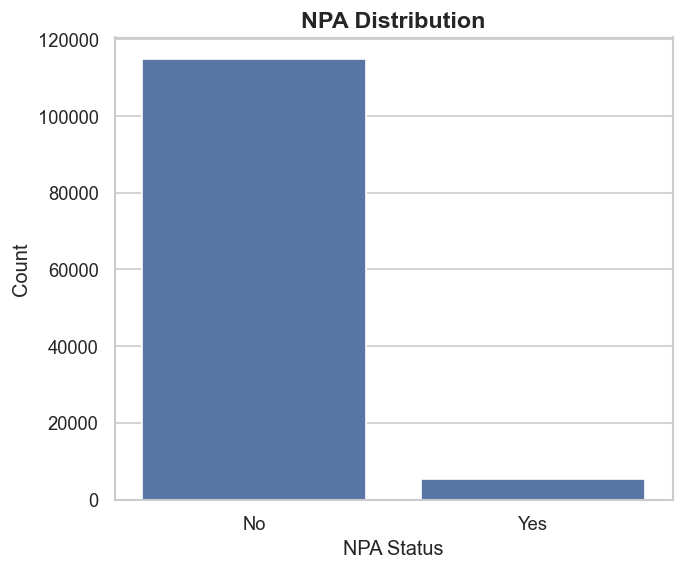

In [56]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=npa,
    x="NPA Status",
    y="Count"
)

plt.title("NPA Distribution", fontsize=14, fontweight="bold")

plt.show()

In [57]:
npa_rate = (df["npa_flag"] == "Yes").mean() * 100

print(f"""
📌 Executive Insight

• Overall NPA Rate : {npa_rate:.2f}%

• Monitoring NPAs helps assess portfolio quality and recovery performance.
""")


📌 Executive Insight

• Overall NPA Rate : 4.36%

• Monitoring NPAs helps assess portfolio quality and recovery performance.



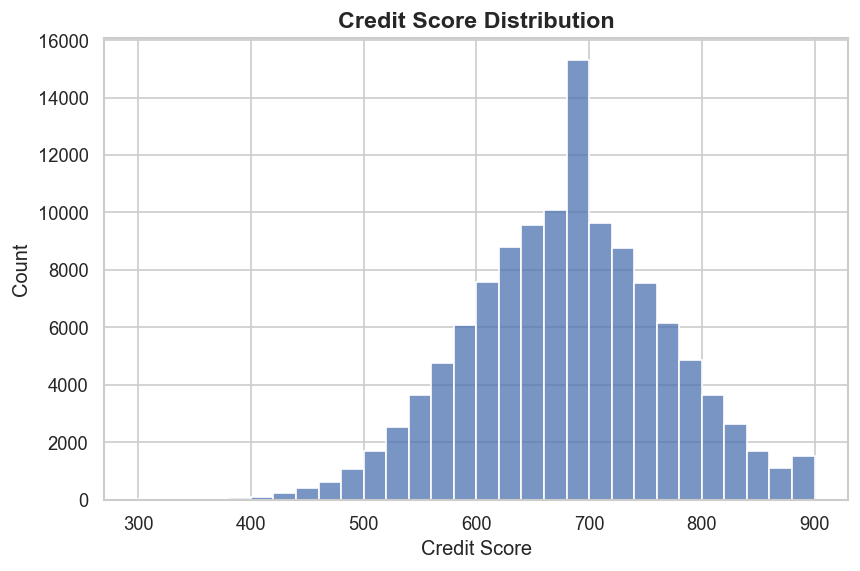

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["credit_score"],
    bins=30
)

plt.title("Credit Score Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Credit Score")

plt.show()

In [59]:
print(f"""
📌 Executive Insight

Average Credit Score : {df['credit_score'].mean():.0f}

Median Credit Score : {df['credit_score'].median():.0f}

Higher credit scores generally indicate lower credit risk.
""")


📌 Executive Insight

Average Credit Score : 680

Median Credit Score : 680

Higher credit scores generally indicate lower credit risk.



In [63]:
fraud = (
    df["is_fraud_suspected"]
    .value_counts()
    .reset_index()
)

fraud.columns = ["Fraud Suspected", "Count"]

fraud

,Fraud Suspected,Count
0,No,119492
1,Yes,508


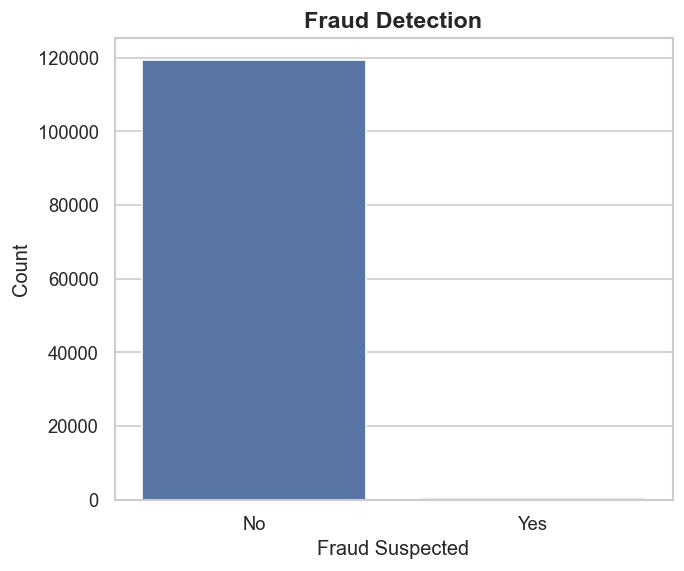

In [64]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=fraud,
    x="Fraud Suspected",
    y="Count"
)

plt.title("Fraud Detection", fontsize=14, fontweight="bold")

plt.show()

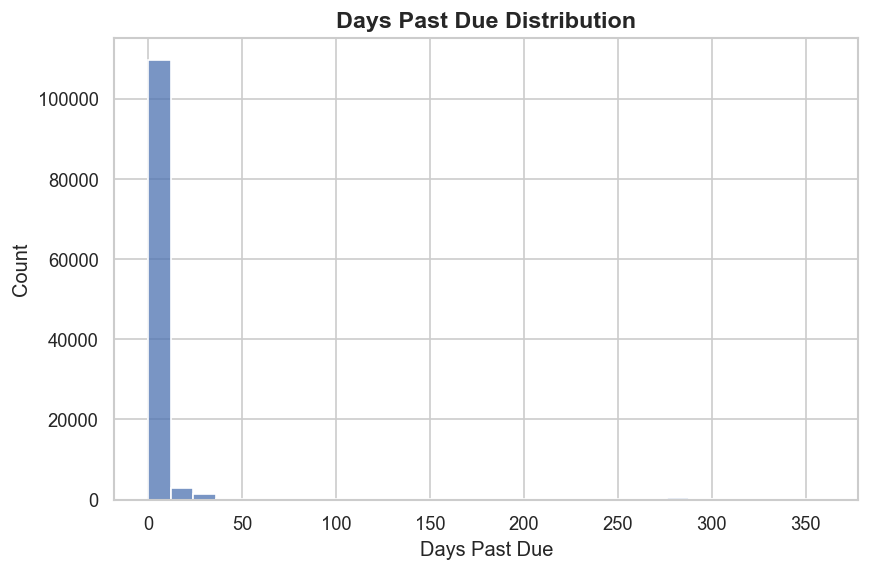

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["days_past_due"],
    bins=30
)

plt.title("Days Past Due Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Days Past Due")

plt.show()

In [66]:
print(f"""
📌 Executive Insight

Average DPD : {df['days_past_due'].mean():.1f} days

Higher DPD values indicate increased repayment risk and potential NPA formation.
""")


📌 Executive Insight

Average DPD : 10.7 days

Higher DPD values indicate increased repayment risk and potential NPA formation.



In [67]:
# # 💰 Financial Dashboard

# ### Objectives

# - Loan Amount Analysis
# - Disbursed Amount Analysis
# - Recovery Amount Analysis
# - EMI Distribution
# - Interest Rate Distribution
# # - Processing Fee Distribution

In [68]:
loan_stats = df["loan_amount"].describe().round(2)

loan_stats

count      120000.00
mean       608106.27
std        563429.67
min         50000.00
25%        296000.00
50%        482000.00
75%        770000.00
max      45395890.03
Name: loan_amount, dtype: float64

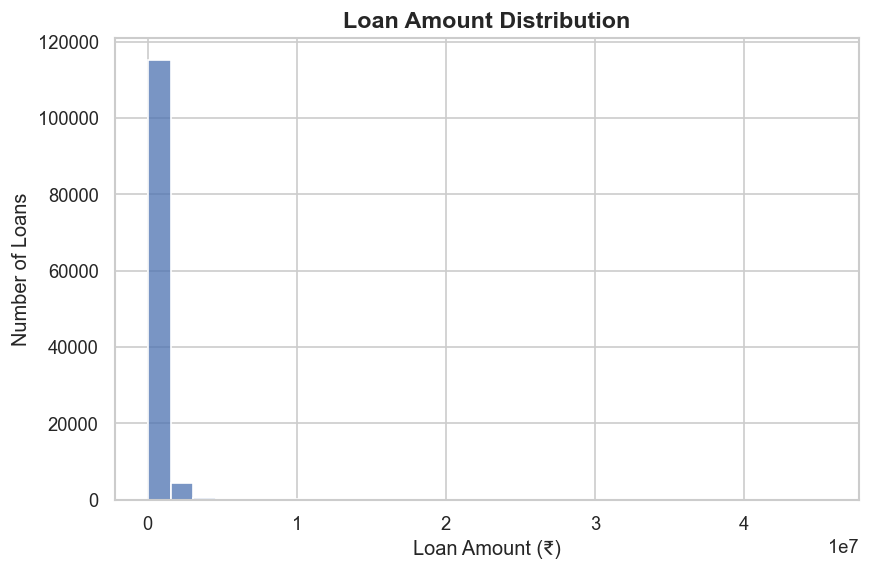

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="loan_amount",
    bins=30
)

plt.title("Loan Amount Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Loan Amount (₹)")
plt.ylabel("Number of Loans")

plt.show()

In [70]:
print(f"""
📌 Executive Insight

Average Loan Amount : ₹{df['loan_amount'].mean():,.0f}

Median Loan Amount : ₹{df['loan_amount'].median():,.0f}

The portfolio is centered around the average loan amount, indicating the institution's primary lending range.
""")


📌 Executive Insight

Average Loan Amount : ₹608,106

Median Loan Amount : ₹482,000

The portfolio is centered around the average loan amount, indicating the institution's primary lending range.



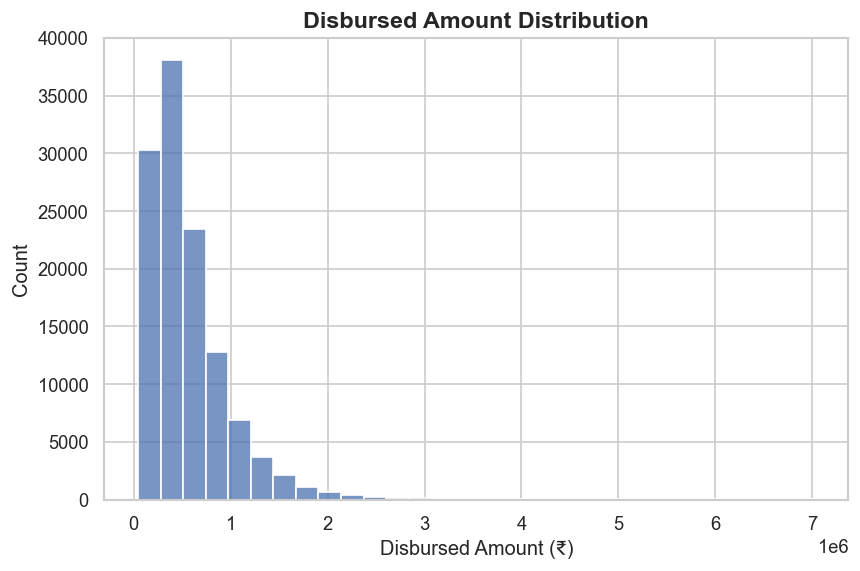

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="disbursed_amount",
    bins=30
)

plt.title("Disbursed Amount Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Disbursed Amount (₹)")

plt.show()

In [72]:
print(f"""
📌 Executive Insight

Total Disbursed Amount :

₹{df['disbursed_amount'].sum():,.0f}

The institution has disbursed a substantial loan portfolio across customers.
""")


📌 Executive Insight

Total Disbursed Amount :

₹67,165,376,000

The institution has disbursed a substantial loan portfolio across customers.



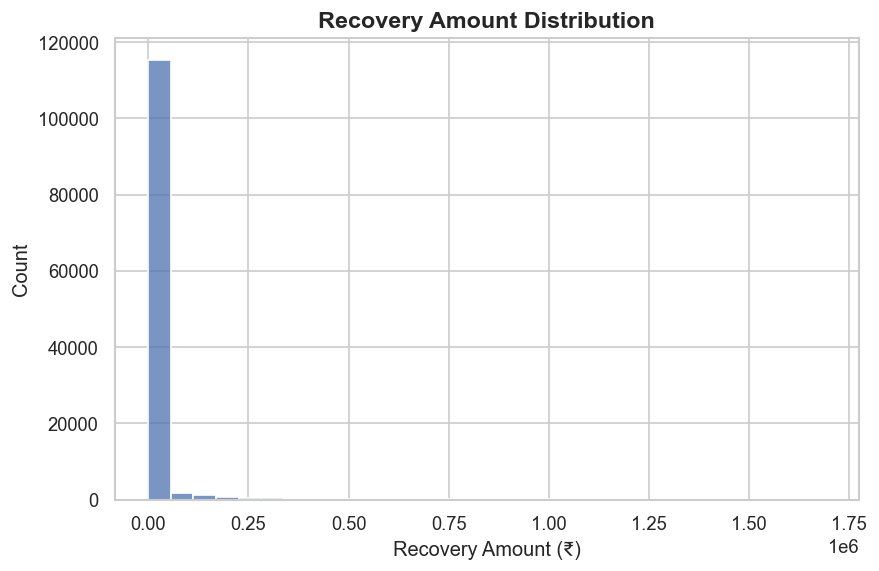

In [75]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="recovery_amount",
    bins=30
)

plt.title("Recovery Amount Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Recovery Amount (₹)")

plt.show()

In [76]:
print(f"""
📌 Executive Insight

Total Recovery :

₹{df['recovery_amount'].sum():,.0f}

Recovery performance reflects portfolio collection efficiency.
""")


📌 Executive Insight

Total Recovery :

₹912,425,445

Recovery performance reflects portfolio collection efficiency.



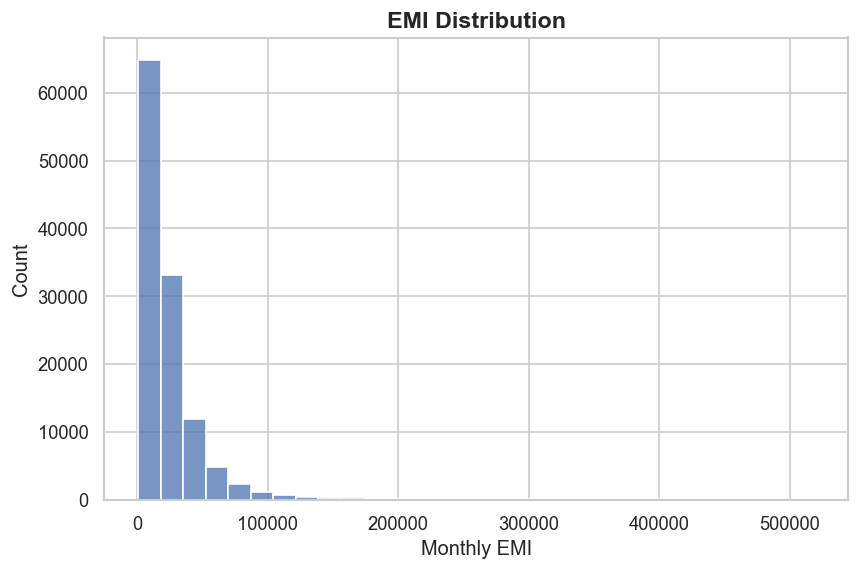

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="emi_amount",
    bins=30
)

plt.title("EMI Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Monthly EMI")

plt.show()

In [78]:
print(f"""
📌 Executive Insight

Average EMI :

₹{df['emi_amount'].mean():,.0f}

EMI values indicate repayment affordability across customers.
""")


📌 Executive Insight

Average EMI :

₹23,638

EMI values indicate repayment affordability across customers.



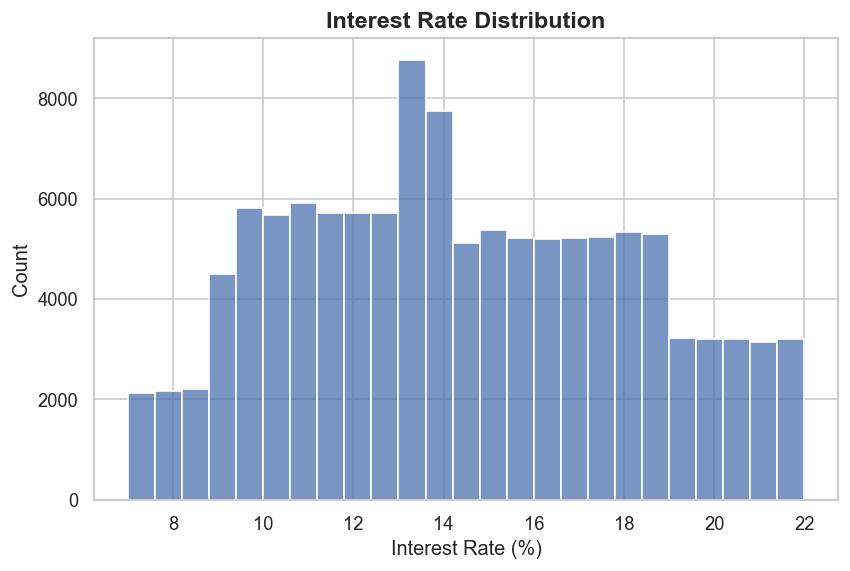

In [79]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="interest_rate",
    bins=25
)

plt.title("Interest Rate Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Interest Rate (%)")

plt.show()

In [80]:
print(f"""
📌 Executive Insight

Average Interest Rate :

{df['interest_rate'].mean():.2f}%

Interest rate distribution reflects the pricing strategy adopted for different borrower profiles.
""")


📌 Executive Insight

Average Interest Rate :

14.39%

Interest rate distribution reflects the pricing strategy adopted for different borrower profiles.



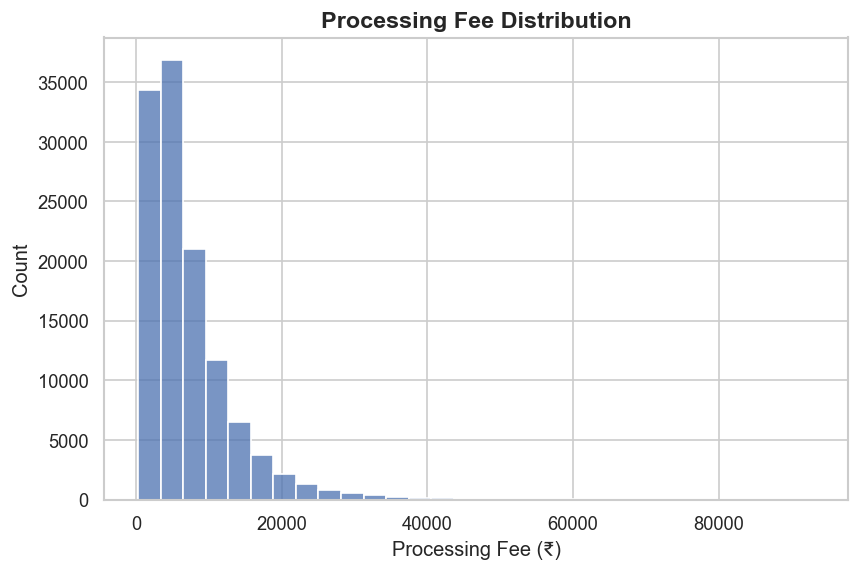

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="processing_fee",
    bins=30
)

plt.title("Processing Fee Distribution", fontsize=14, fontweight="bold")

plt.xlabel("Processing Fee (₹)")

plt.show()

In [82]:
print(f"""
📌 Executive Insight

Average Processing Fee :

₹{df['processing_fee'].mean():,.0f}

Processing fees contribute to non-interest income while covering loan processing costs.
""")


📌 Executive Insight

Average Processing Fee :

₹7,086

Processing fees contribute to non-interest income while covering loan processing costs.

